In [2]:
from sys import path

path.append("..")

import os
from pathlib import Path

os.chdir(Path.cwd().parent)

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from src.graph_utils.reading import read_metadata
from src.settings import Settings


In [4]:
metadata = read_metadata()

In [5]:
from collections import Counter

def count_elements(row_array):
    if len(row_array) == 1 and row_array[0] == -1:
        return 0
    return len(row_array)

test_data = pd.read_parquet(Settings.processed_datasets_dir / 'table.parquet')
test_data['count'] = test_data['result'].apply(count_elements)

test_data['percentage'] = test_data.apply(lambda x: x['count'] / metadata[x['dataset_name']]['graph_count'], axis=1)

In [6]:
test_data = test_data.reset_index(drop=True)
test_data

,features,dataset_name,result,count,percentage
0,[jaccard_index],graph5,"[2, 5, 3, 6, 8, 4, 10, 13, 20, 11, 12, 21, 9, ...",18,0.529412
1,[jaccard_index_normalized],graph5,"[2, 5, 3, 6, 8, 4, 10, 13, 20, 15, 26]",11,0.323529
2,[adamic_adar],graph5,"[2, 5, 3, 6, 8, 4, 10, 13, 20, 15, 26]",11,0.323529
3,[katz_index],graph5,"[2, 5, 3, 6, 8, 4, 10, 13, 20, 11, 12, 21, 9, ...",18,0.529412
4,[neighborhood_distance],graph5,"[2, 5, 3, 6, 8, 4, 10, 13, 20, 15, 26]",11,0.323529
...,...,...,...,...,...
6595,"[degree_centrality_normalized, degree_centrali...",sr361566,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",32548,1.000000
6596,"[katz_centrality, katz_centrality:k_graph2, ka...",sr361566,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",32548,1.000000
6597,"[lcc, lcc:k_graph2, lcc:k_graph3]",sr361566,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",32548,1.000000
6598,"[ldp_degree, ldp_degree:k_graph2, ldp_degree:k...",sr361566,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",32548,1.000000


In [7]:
test_data['result'].iloc[0]

array([ 2,  5,  3,  6,  8,  4, 10, 13, 20, 11, 12, 21,  9, 19, 16, 24, 15,
       26])

In [8]:

test_data['features'] = test_data['features'].astype('string').astype('category')
test_data.columns

Index(['features', 'dataset_name', 'result', 'count', 'percentage'], dtype='object')

In [9]:
test_data.sort_values('count').head(20)

,features,dataset_name,result,count,percentage
4793,['closeness_normalized' 'closeness_normalized:...,highlyirregular11,[-1],0,0.0
5974,['neighborhood_distance' 'neighborhood_distanc...,selfcomp9,[-1],0,0.0
5973,['katz_index' 'katz_index:k_graph2' 'katz_inde...,selfcomp9,[-1],0,0.0
5972,['adamic_adar' 'adamic_adar:k_graph2' 'adamic_...,selfcomp9,[-1],0,0.0
5971,['jaccard_index_normalized' 'jaccard_index_nor...,selfcomp9,[-1],0,0.0
5970,['jaccard_index' 'jaccard_index:k_graph2' 'jac...,selfcomp9,[-1],0,0.0
5950,['algebraic_distance:modk_graph3'],selfcomp9,[-1],0,0.0
1369,['edge_betweenness_normalized'],eul9,[-1],0,0.0
1368,['edge_betweenness'],eul9,[-1],0,0.0
5990,['spanning_edge' 'spanning_edge:k_graph2' 'spa...,selfcomp9,[-1],0,0.0


In [14]:
import os
os.listdir('datasets/raw')

['.gitkeep',
 'chordal10.g6',
 'chordal6.g6',
 'chordal7.g6',
 'chordal8.g6',
 'chordal9.g6',
 'eul10.g6',
 'eul6.g6',
 'eul7.g6',
 'eul8.g6',
 'eul9.g6',
 'ge10c.g6',
 'graph4c.g6',
 'graph5.g6',
 'graph6.g6',
 'graph7.g6',
 'graph7c.g6',
 'graph8.g6',
 'graph8c.g6',
 'graph9.g6',
 'graph9c.g6',
 'highlyirregular11.g6',
 'highlyirregular12.g6',
 'highlyirregular13.g6',
 'highlyirregular14.g6',
 'highlyirregular15.g6',
 'metadata.json',
 'perfect6.g6',
 'perfect7.g6',
 'perfect8.g6',
 'perfect9.g6',
 'planar_conn.5.g6',
 'planar_conn.6.g6',
 'planar_conn.7.g6',
 'planar_conn.8.g6',
 'planar_conn.9.g6',
 'regular-2000.g6',
 'regular.g6',
 'selfcomp12.g6',
 'selfcomp13.g6',
 'selfcomp9.g6',
 'sr291467.g6',
 'sr351668.g6',
 'sr351899.g6',
 'sr361446.g6',
 'sr361566.g6',
 'sr371889some.g6',
 'sr401224.g6',
 'sr65321516some.g6']

In [10]:
# data2d = test_data[~test_data['features'].str.contains(' ')].pivot(index="features", columns="dataset_name", values="percentage")
# data2d = test_data[test_data['features'].str.contains(':k_graph2')].pivot(index="features", columns="dataset_name", values="percentage")
data2d = test_data.pivot(index="features", columns="dataset_name", values="percentage")

data2d = data2d.sort_index()

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = 1 - data2d

# mean
mean_score = df.mean(axis=1)

# power mean
def power_mean(df, p, epsilon=1e-12):
    df_safe = df + epsilon
    
    if p == 0:
        return np.exp(np.log(df_safe).mean(axis=1))
    else:
        return (df_safe.pow(p).mean(axis=1)) ** (1 / p)

# różne p (to miało być Twoim celem)
p0_score = power_mean(df, p=0)    # geometric
p_1_score = power_mean(df, p=-1)  # harmonic
p_2_score = power_mean(df, p=-2)    # strong penalty for zeros


# size
sizes = pd.Series({
    dataset: metadata[dataset]['graph_count']
    for dataset in df.columns
})
weights_size = sizes / sizes.sum()

weighted_mean_size = (df * weights_size).sum(axis=1)

# difficulty
dataset_difficulty = df.mean(axis=0)
difficulty_weights = dataset_difficulty / dataset_difficulty.sum()

weighted_mean_difficulty = (df * difficulty_weights).sum(axis=1)

results = pd.DataFrame({
    "mean": mean_score,
    "p=0 (geom)": p0_score,
    "p=-1 (harm)": p_1_score,
    "p=-2": p_2_score,
    "weighted_size": weighted_mean_size,
    "weighted_difficulty": weighted_mean_difficulty
})


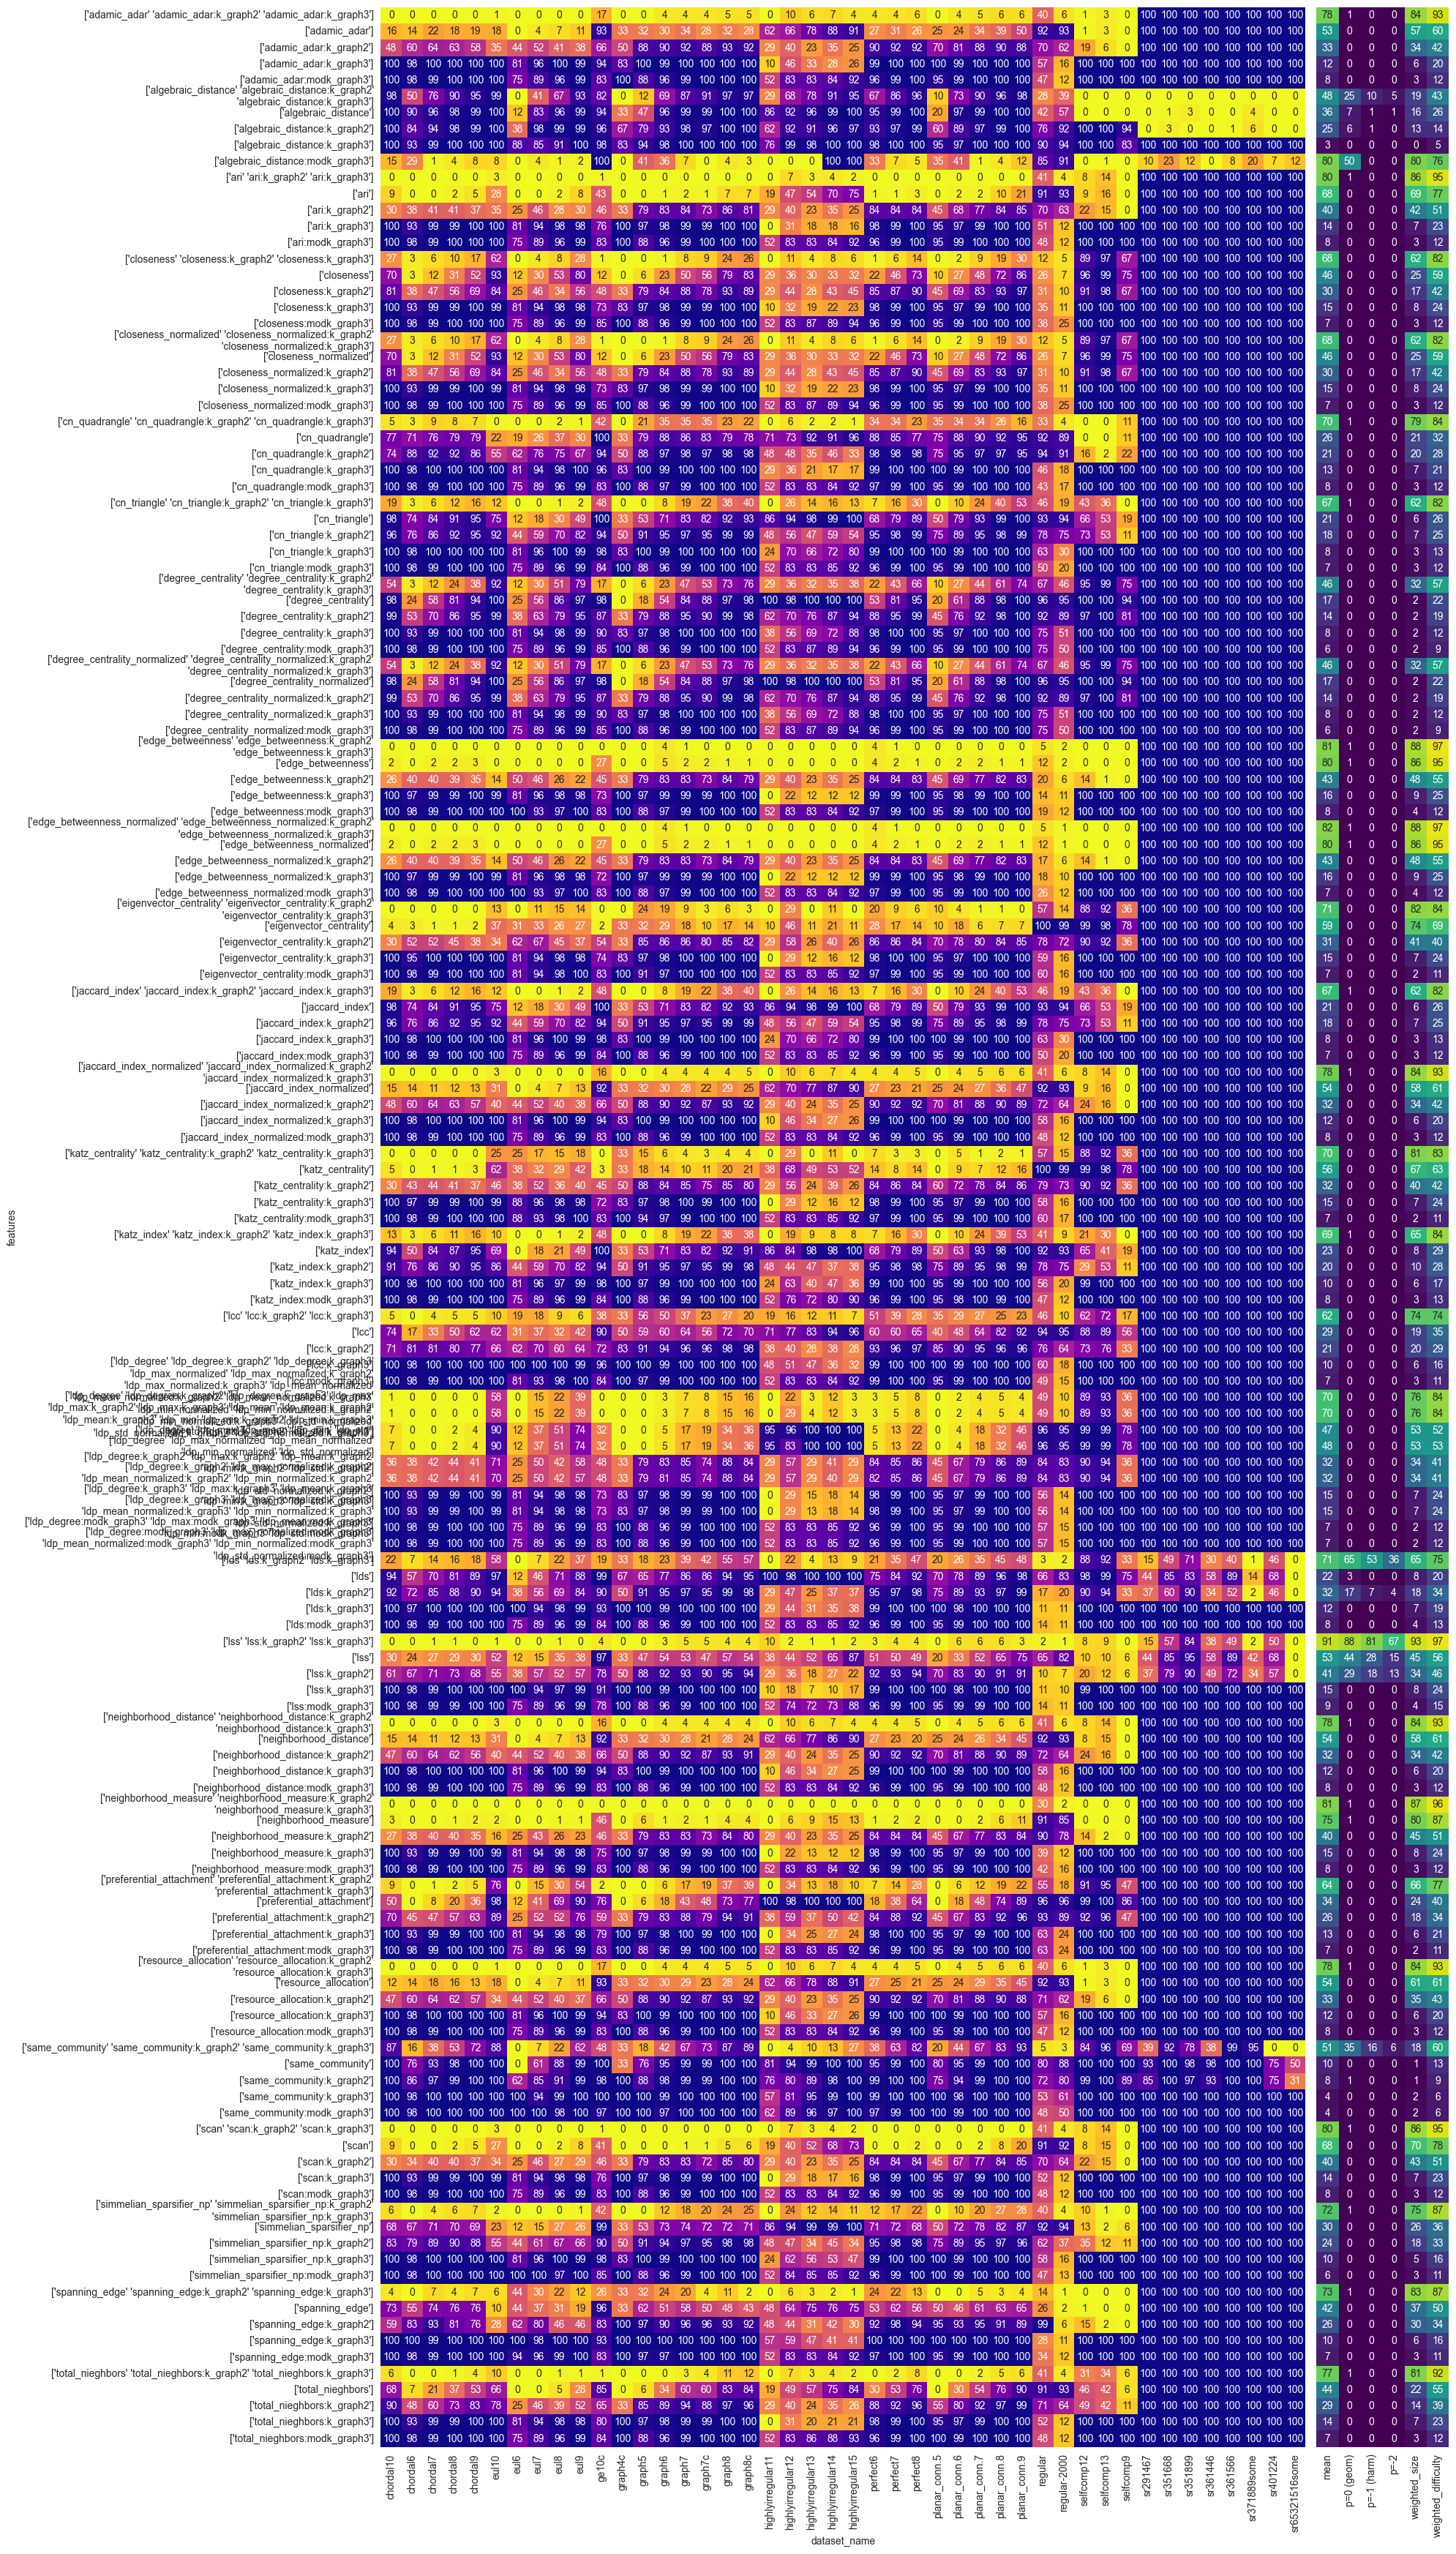

In [12]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(20, 35),
    gridspec_kw={'width_ratios': [7, 1]}
)

sns.heatmap(
    data2d,
    cmap='plasma_r',
    vmin=0, vmax=1,
    annot=np.round(data2d * 100, 1),
    fmt=".0f",
    cbar=False,
    ax=ax1
)

sns.heatmap(
    results,
    cmap='viridis',
    vmin=0, vmax=1,
    annot=np.round(results * 100, 1),
    fmt=".0f",
    cbar=False,
    ax=ax2
)
ax2.set_yticks([])
ax2.set_ylabel("")

plt.tight_layout()